In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cvx

In [76]:
def f_obj(x,y):
    return (x+2)**2 + (y-1)**2


def cline(x,y):
    return x-y

L = 100
xmin = -5
xmax = 5
ymin = -5
ymax =5
xx = np.linspace(xmin, xmax, L)
yy = np.linspace(ymin, ymax, L)
X, Y = np.meshgrid(xx, yy)

f_Z = f_obj(X,Y)

In [9]:
f_Z.shape

(100, 100)

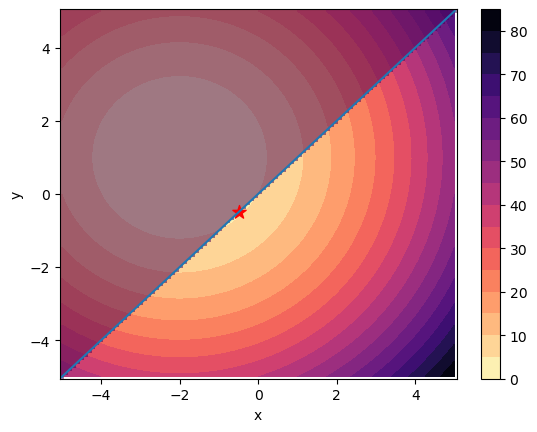

In [98]:
x_var = cvx.Variable()
y_var = cvx.Variable()

obj = cvx.square(x_var+2) + cvx.square(y_var-1)
constr = -x_var+y_var

prob = cvx.Problem(cvx.Minimize(obj),[constr<=0])

prob.solve()



Z_Reg = X > Y
Z_Reg_nan = np.where(Z_Reg, np.nan, Z_Reg)
plt.contourf(X, Y, f_Z, levels=20, cmap='magma_r')
plt.colorbar(extend="both")
plt.plot(xx,yy)

plt.pcolormesh(X,Y,Z_Reg_nan,alpha=0.5)
plt.scatter(x_var.value,y_var.value,s=100,marker="*",color="Red")


plt.xlabel('x')
plt.ylabel('y')
plt.title('')
plt.show()

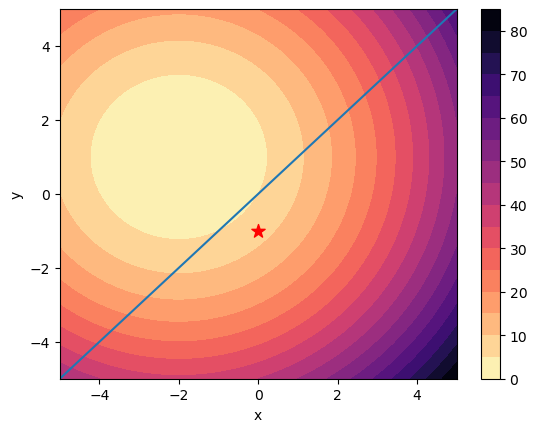

In [94]:
l = 4.0
x_var = cvx.Variable()
y_var = cvx.Variable()

obj = cvx.square(x_var+2) + cvx.square(y_var-1)
constr = -x_var+y_var

prob = cvx.Problem(cvx.Minimize(obj+l*constr))

prob.solve()



f_Z_tilt = f_obj(X,Y) + l*(X-Y)
plt.contourf(X, Y, f_Z, levels=20, cmap='magma_r')
plt.colorbar(extend="both")
plt.plot(xx,yy)

plt.scatter(x_var.value,y_var.value,s=100,marker="*",color="Red")


plt.xlabel('x')
plt.ylabel('y')
plt.title('')
plt.show()


In [99]:
prob.solution.dual_vars

{1404: array(3.)}

In [105]:
l=-0
prob = cvx.Problem(cvx.Minimize(obj+l*constr))

prob.solve()

0.0

In [107]:
prob.solution.dual_vars

{}

In [36]:
Z_Reg[Z_Reg == True] = np.nan*Z_Reg[Z_Reg == True]

In [38]:
Z_Reg[np.where(Z_Reg)] = np.nan

In [40]:
Z_Reg_nan = np.where(Z_Reg, np.nan, Z_Reg)

In [35]:
cvx.squ

nan

In [41]:
Z_Reg_nan

array([[ 0., nan, nan, ..., nan, nan, nan],
       [ 0.,  0., nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       ...,
       [ 0.,  0.,  0., ...,  0., nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0., nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [57]:
x_var.value

array(-2.49985707e-30)

In [58]:
y_var.value

array(2.49985707e-30)

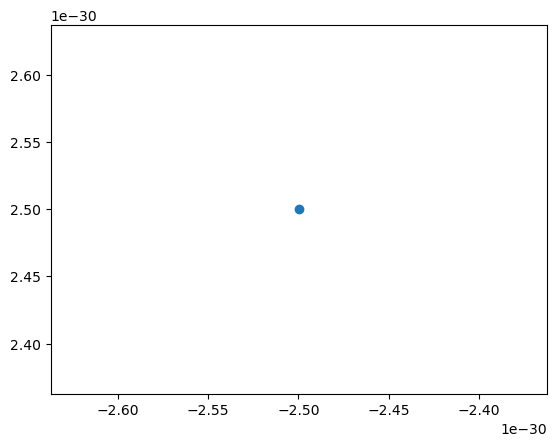

In [62]:
plt.scatter(x_var.value,y_var.value)


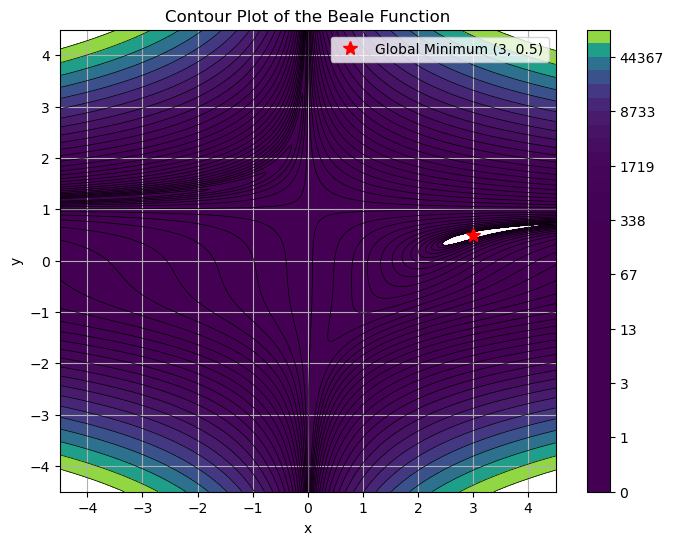

In [108]:

# Beale function definition
def beale(x, y):
    return ((1.5 - x + x*y)**2 + 
            (2.25 - x + x*y**2)**2 + 
            (2.625 - x + x*y**3)**2)

# Create a grid of points
x = np.linspace(-4.5, 4.5, 400)
y = np.linspace(-4.5, 4.5, 400)
X, Y = np.meshgrid(x, y)
Z = beale(X, Y)

# Plotting
plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, levels=np.logspace(-1, 5, 35), cmap='viridis')
plt.colorbar(cp)
plt.contour(X, Y, Z, levels=np.logspace(-1, 5, 35), colors='black', linewidths=0.5)

# Global minimum
plt.plot(3, 0.5, 'r*', markersize=10, label='Global Minimum (3, 0.5)')

plt.title('Contour Plot of the Beale Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()